# Flight Delay Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on flight delay data using AWS Athena and `awswrangler`. It queries the data and builds visualizations to uncover patterns in delays related to time, carrier, and distance.

In [1]:
import os
import warnings
import boto3
from botocore.exceptions import ClientError
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress noisy Ray memory and future deprecation warnings
warnings.filterwarnings("ignore")
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

## Athena Results Bucket Setup

In [2]:
session = boto3.Session()
region = session.region_name if session.region_name else "us-east-1"
sts = session.client("sts")
account_id = sts.get_caller_identity()["Account"]

results_bucket = f"aws-athena-query-results-{account_id}-{region}"
athena_s3_output = f"s3://{results_bucket}/"
s3 = session.client("s3", region_name=region)

print(f"Checking Athena results bucket: {results_bucket}...")
try:
    s3.head_bucket(Bucket=results_bucket)
    print("Bucket exists. Using for query results.\n")
except ClientError as e:
    error_code = e.response.get('Error', {}).get('Code')
    if error_code == '404':
        print("Bucket not found. Creating bucket...")
        if region == "us-east-1":
            s3.create_bucket(Bucket=results_bucket)
        else:
            s3.create_bucket(
                Bucket=results_bucket,
                CreateBucketConfiguration={'LocationConstraint': region}
            )
        print("Bucket created successfully.\n")
    else:
        raise e

Checking Athena results bucket: aws-athena-query-results-935073302946-us-east-1...
Bucket exists. Using for query results.



## EDA Configuration & Visualization Settings

In [3]:
athena_db = "aai540_group1"
clean_table = "clean_flights_full"

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Executing EDA queries against {athena_db}.{clean_table}...")

Executing EDA queries against aai540_group1.clean_flights_full...


## Class Balance

Fetching Class Balance...


2026-09-20 18:54:40,299	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 1938792448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.37gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-09-20 18:54:45,451	INFO worker.py:2012 -- Started a local Ray instance.


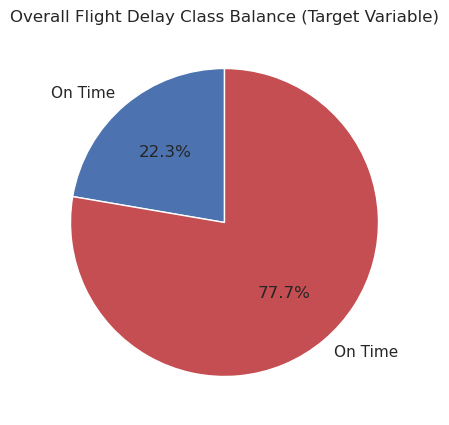

In [4]:
print("Fetching Class Balance...")
query_balance = f"""
SELECT
    CASE WHEN arrdel15 = '1.0' THEN 'Delayed (>= 15m)' ELSE 'On Time' END AS status,
    COUNT(*) AS flight_count
FROM {clean_table}
GROUP BY arrdel15
"""
df_balance = wr.athena.read_sql_query(query_balance, database=athena_db, s3_output=athena_s3_output)

plt.figure(figsize=(8, 5))
plt.pie(df_balance['flight_count'], labels=df_balance['status'], autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
plt.title("Overall Flight Delay Class Balance (Target Variable)")
plt.show()

## Temporal Patterns (Month & Day of Week)

Fetching Temporal Patterns...


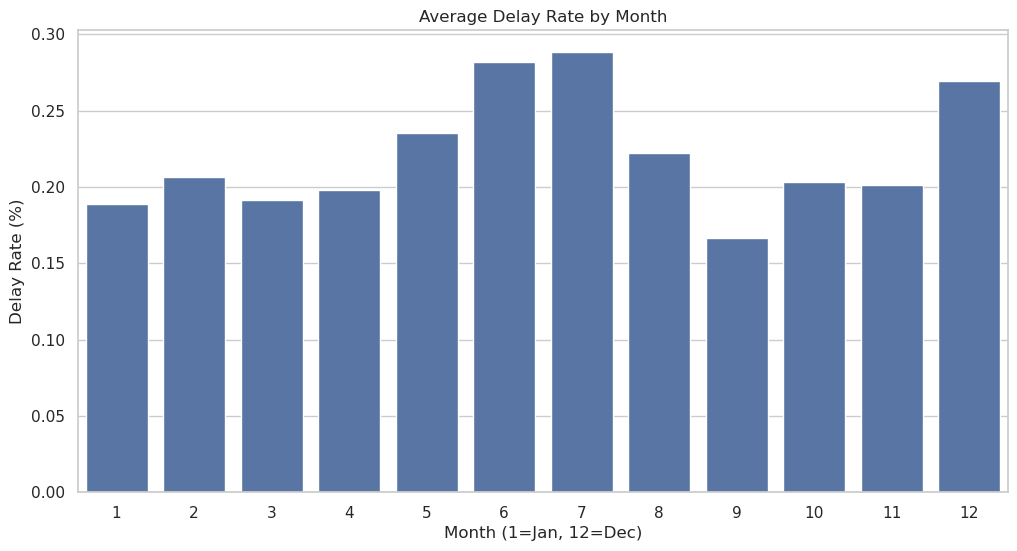

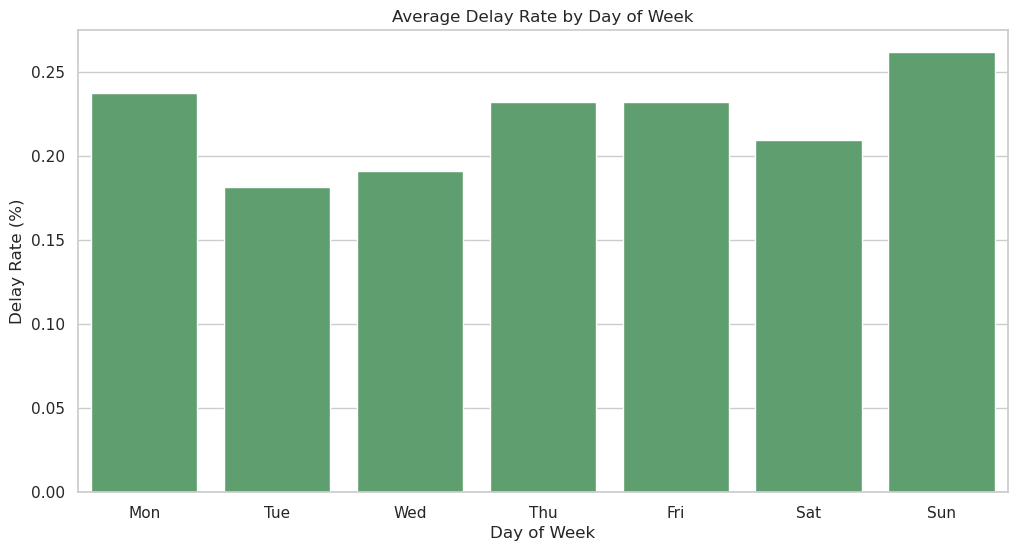

In [5]:
print("Fetching Temporal Patterns...")
query_temporal = f"""
SELECT
    CAST(month AS INT) AS month,
    CAST(dayofweek AS INT) AS day_of_week,
    AVG(CAST(arrdel15 AS DOUBLE)) AS delay_rate,
    COUNT(*) AS total_flights
FROM {clean_table}
GROUP BY month, dayofweek
"""
df_temporal = wr.athena.read_sql_query(query_temporal, database=athena_db, s3_output=athena_s3_output)

# Aggregate for Month
df_month = df_temporal.groupby('month')['delay_rate'].mean().reset_index()
plt.figure()
sns.barplot(data=df_month, x='month', y='delay_rate', color="#4C72B0")
plt.title("Average Delay Rate by Month")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.show()

# Aggregate for Day of Week
df_dow = df_temporal.groupby('day_of_week')['delay_rate'].mean().reset_index()
days = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
df_dow['day_name'] = df_dow['day_of_week'].map(days)

plt.figure()
sns.barplot(data=df_dow, x='day_name', y='delay_rate', color="#55A868")
plt.title("Average Delay Rate by Day of Week")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Day of Week")
plt.show()

## Airline / Carrier Performance

Fetching Airline Performance...


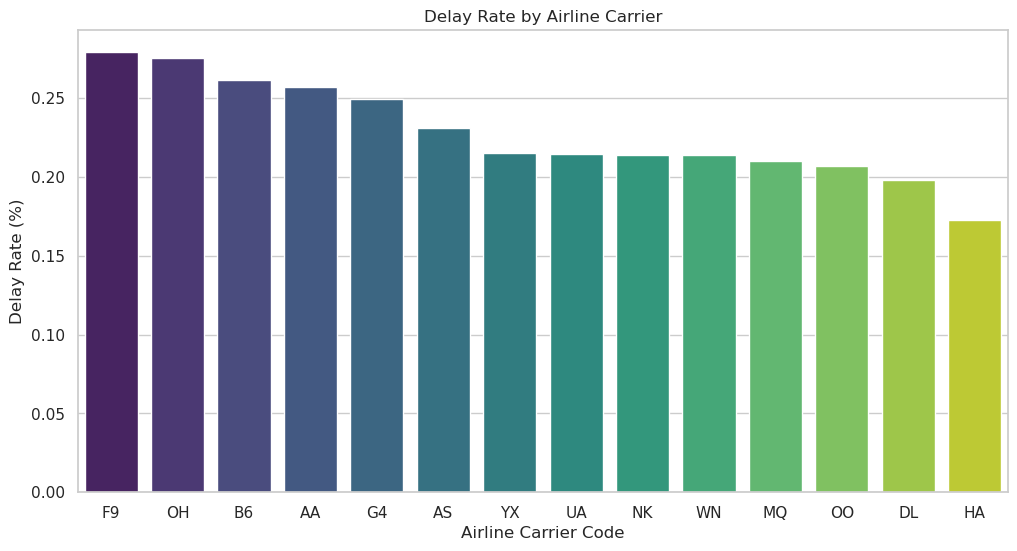

In [6]:
print("Fetching Airline Performance...")
query_carrier = f"""
SELECT
    opuniquecarrier AS airline,
    AVG(CAST(arrdel15 AS DOUBLE)) AS delay_rate,
    COUNT(*) AS total_flights
FROM {clean_table}
GROUP BY opuniquecarrier
HAVING COUNT(*) > 10000
ORDER BY delay_rate DESC
"""
df_carrier = wr.athena.read_sql_query(query_carrier, database=athena_db, s3_output=athena_s3_output)

plt.figure()
sns.barplot(data=df_carrier, x='airline', y='delay_rate', palette="viridis")
plt.title("Delay Rate by Airline Carrier")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Airline Carrier Code")
plt.show()

## Departure Hour

Fetching Departure Hour Trends...


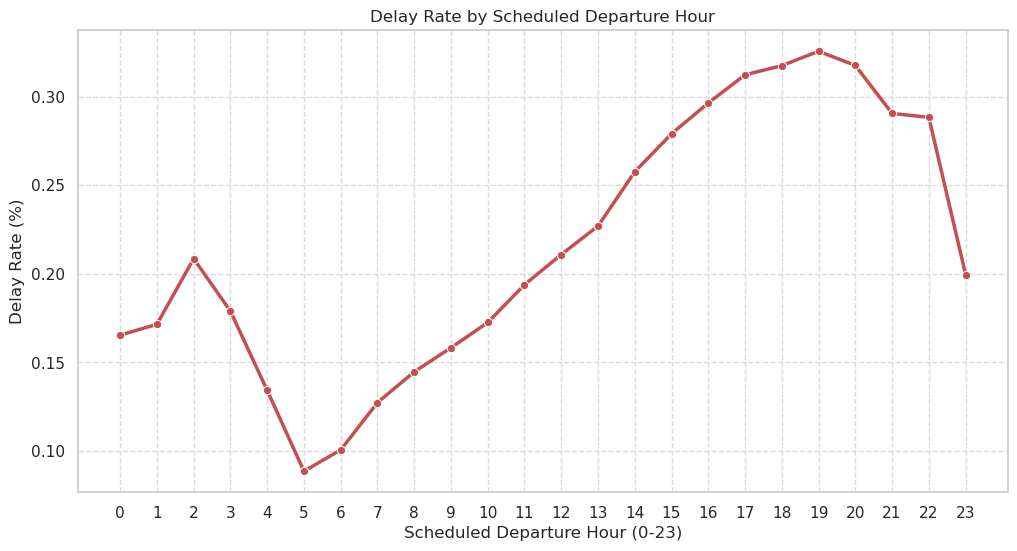

In [7]:
print("Fetching Departure Hour Trends...")
query_hour = f"""
SELECT
    CAST(FLOOR(CAST(crsdeptime AS DOUBLE) / 100) AS INT) AS scheduled_dep_hour,
    AVG(CAST(arrdel15 AS DOUBLE)) AS delay_rate,
    COUNT(*) as total_flights
FROM {clean_table}
WHERE TRY_CAST(crsdeptime AS DOUBLE) IS NOT NULL
GROUP BY CAST(FLOOR(CAST(crsdeptime AS DOUBLE) / 100) AS INT)
ORDER BY scheduled_dep_hour
"""
df_hour = wr.athena.read_sql_query(query_hour, database=athena_db, s3_output=athena_s3_output)

# Filter valid 24-hour clock values
df_hour = df_hour[(df_hour['scheduled_dep_hour'] >= 0) & (df_hour['scheduled_dep_hour'] <= 23)]

plt.figure()
sns.lineplot(data=df_hour, x='scheduled_dep_hour', y='delay_rate', marker="o", color="#C44E52", linewidth=2.5)
plt.title("Delay Rate by Scheduled Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Scheduled Departure Hour (0-23)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Flight Distance vs Delay Rate (Binned)

Fetching Distance Distributions...


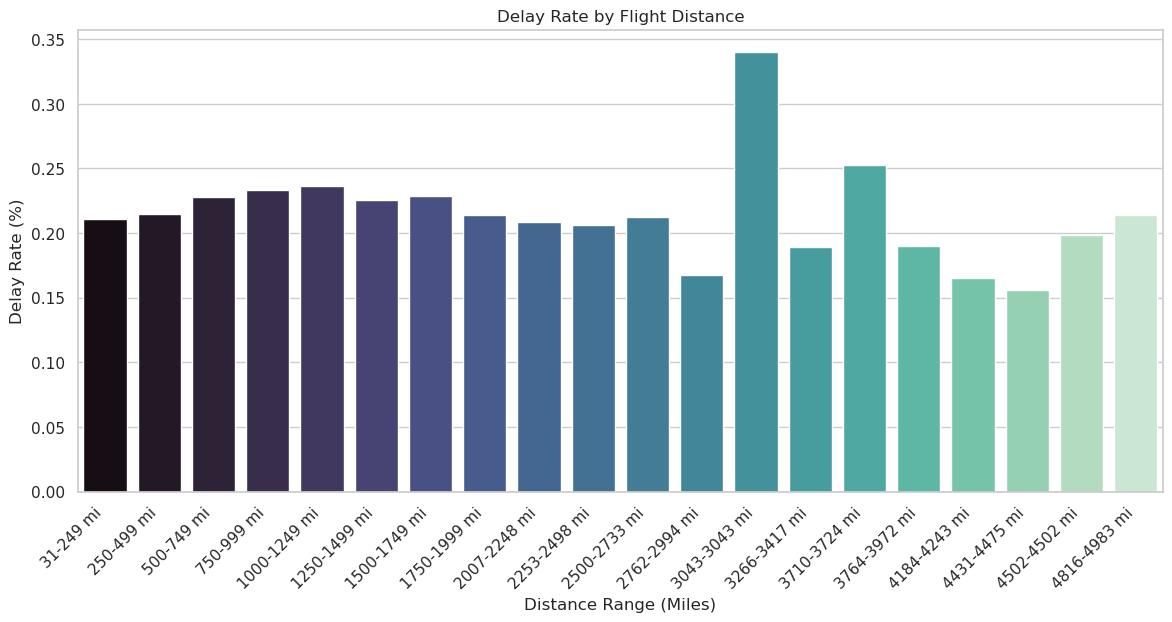

In [8]:
print("Fetching Distance Distributions...")
query_distance = f"""
SELECT
    WIDTH_BUCKET(CAST(distance AS DOUBLE), 0, 5000, 20) AS distance_bin,
    MIN(CAST(distance AS DOUBLE)) AS min_dist,
    MAX(CAST(distance AS DOUBLE)) AS max_dist,
    AVG(CAST(arrdel15 AS DOUBLE)) AS delay_rate,
    COUNT(*) as flight_count
FROM {clean_table}
WHERE TRY_CAST(distance AS DOUBLE) IS NOT NULL
GROUP BY WIDTH_BUCKET(CAST(distance AS DOUBLE), 0, 5000, 20)
ORDER BY distance_bin
"""
df_distance = wr.athena.read_sql_query(query_distance, database=athena_db, s3_output=athena_s3_output)

df_distance['bin_label'] = df_distance['min_dist'].astype(int).astype(str) + "-" + df_distance['max_dist'].astype(int).astype(str) + " mi"
df_distance = df_distance[df_distance['distance_bin'] <= 20]

plt.figure(figsize=(14, 6))
sns.barplot(data=df_distance, x='bin_label', y='delay_rate', palette="mako")
plt.title("Delay Rate by Flight Distance")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Distance Range (Miles)")
plt.xticks(rotation=45, ha='right')
plt.show()